# Capillary-breakup (CaBER) video analysis — `cabervideo` quickstart

End-to-end demo of filament-thinning analysis with the `cabervideo` helper module:
load a capillary-breakup video → track the filament radius frame by frame →
calibrate pixels to metres → fit the linear thinning regime → extensional viscosity & Trouton ratio.

> ⚠️ **Kernel requirement.** This notebook needs OpenCV (`cv2`), which has no Pyodide build,
> so it cannot run in the JupyterLite in-browser kernel. Run it on a full Python kernel
> (local Jupyter, Colab, Binder). The interactive bounding-box selector additionally needs
> an interactive matplotlib backend (`ipympl`); a programmatic mask is used by default so the
> notebook also runs headless.

`cabervideo` is a single-file helper that lives with this demo in the rheolite repository
(`content/capyllarybreakup/cabervideo.py`) — it is not on PyPI, so the notebook below
fetches it automatically if it is not already next to the notebook.

In [ ]:
%pip install -q opencv-python-headless ipywidgets lmfit openpyxl pillow

In [ ]:
# --- fetch the cabervideo helper module (single file in the rheolite repo) ---
import importlib, pathlib, sys, urllib.request

CABER_URL = ("https://raw.githubusercontent.com/rheopy/rheolite/main/"
             "content/capyllarybreakup/cabervideo.py")

def _ensure_cabervideo():
    try:
        import cabervideo  # noqa
        return
    except ImportError:
        pass
    dest = pathlib.Path('cabervideo.py')
    print(f"downloading cabervideo.py from the rheolite repo ...")
    urllib.request.urlretrieve(CABER_URL, dest)
    print(f"saved to {dest.resolve()}")

_ensure_cabervideo()
import cabervideo as cv
print("cabervideo imported:", [n for n in dir(cv) if not n.startswith('_')])


## Test video

Upload your own CaBER `.mp4` below, or leave the uploader empty to use the bundled
**synthetic** capillary-breakup video generated in the next cell (a thinning horizontal
filament between two plates, mimicking the camera-sideways geometry of the original demo).
The synthetic video guarantees every cell below runs end-to-end without any upload.

In [ ]:
import numpy as np

def make_synthetic_caber_video(path='synthetic_caber.mp4', n_frames=150,
                               width=640, height=480, fps=60, seed=7):
    """Write a synthetic CaBER-like video: dark plates + thinning horizontal filament on bright bg."""
    import cv2
    BG, DARK = 200, 25
    fil_y, gap_l, gap_r = height // 2, 380, 500
    rng = np.random.default_rng(seed)
    writer = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))
    for i in range(n_frames):
        hh = max(2.0, 60.0 * (1 - i / (n_frames - 1)))  # filament half-height: 60 -> 2 px
        img = np.full((height, width), BG, np.uint8)
        img[60:420, 0:gap_l] = DARK                      # left plate mass
        img[60:420, gap_r:width] = DARK                   # right plate mass
        for x in range(gap_l - 40, gap_l):               # tapered neck, left
            wpx = int(round(hh + (60 - hh) * (gap_l - x) / 40))
            img[fil_y - wpx:fil_y + wpx, x] = DARK
        for x in range(gap_r, gap_r + 40):               # tapered neck, right
            wpx = int(round(hh + (60 - hh) * (x - gap_r) / 40))
            img[fil_y - wpx:fil_y + wpx, x] = DARK
        img[fil_y - int(round(hh)):fil_y + int(round(hh)), gap_l:gap_r] = DARK  # filament
        img = np.clip(img.astype(float) + rng.normal(0, 6, (height, width)), 0, 255).astype(np.uint8)
        writer.write(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR))
    writer.release()
    return path

video_path = make_synthetic_caber_video()
print("synthetic video written:", video_path)


In [ ]:
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

upload = widgets.FileUpload(accept='.mp4', multiple=False,
                            description='Upload CaBER mp4')
display(upload)


In [ ]:
# Use the uploaded video when present, otherwise the synthetic one.
upload = globals().get('upload')
files = getattr(upload, 'value', None) or ()
if len(files):
    info = files[0]
    video_path = info['name']
    Path(video_path).write_bytes(info['content'])
    print(f"using uploaded video: {video_path} ({len(info['content'])/1e6:.1f} MB)")
else:
    video_path = 'synthetic_caber.mp4'
    print(f"no upload — using synthetic video: {video_path}")


In [ ]:
test_video = cv.CaberVideo(video_path)
print(f"loaded {video_path}: {test_video.num_frames} frames")
test_video.show_frame(0)  # PIL image of the first frame


## Region of interest

`find_radius` flood-fills the bright background from the frame edges, so the default
full-frame mask works when the plates/filament do not touch the image border (as in the
synthetic video and in the original demo video). For interactive use with a desktop
matplotlib backend you can draw a bounding box instead — uncomment the lines below
(requires `ipympl`).

In [ ]:
test_video.reset_mask()  # full frame

# --- optional interactive bounding-box selection (desktop kernel + ipympl only) ---
# get_ipython().run_line_magic('matplotlib', 'ipympl')
# bs = cv.bbox_select(test_video[0])   # draw the box, then:
# test_video.mask = bs.mask

print("mask:", test_video.mask)
test_video.show_frame(0)


In [ ]:
import io
import ipywidgets as widgets
from IPython.display import display

def _frame_png(i):
    buf = io.BytesIO()
    test_video.show_frame(i).save(buf, format='PNG')
    return buf.getvalue()

img_w = widgets.Image(value=_frame_png(0), format='png')
slider = widgets.IntSlider(min=0, max=test_video.num_frames - 1, step=1,
                           value=0, description='Frame:', continuous_update=False)
slider.observe(lambda ch: setattr(img_w, 'value', _frame_png(ch['new'])), names='value')
display(widgets.VBox([slider, img_w]))
print(f"frame inspector ready: {test_video.num_frames} frames")


## Track the filament radius

In [ ]:
res_table = test_video.find_radius_all()
print(res_table.shape)
res_table.head(3)


In [ ]:
res_table.tail(3)

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(res_table['frame_num'], res_table['radius_pixels'], '.', ms=3)
ax.set_xlabel('frame number')
ax.set_ylabel('filament radius [pixels]')
ax.set_title(f"filament thinning — {res_table['filename'].iloc[0]}")
fig.tight_layout()
plt.show()


In [ ]:
# pixels -> metres, frames -> seconds
res_table = cv.calibrate_res_table(res_table)
res_table[['frame_num', 't_s', 'radius_pixels', 'radius_m']].head(3)


# Analysis

Linear elasto-capillary thinning fit, based on [McKinley & Tripathi (2000), *How to extract the Newtonian viscosity from capillary breakup measurements in a filament rheometer*, J. Rheol. 44, 653–670](https://web.mit.edu/nnf/publications/GHM45.pdf).
The filament radius thins approximately linearly in the visco-capillary regime; the slope gives
the extensional viscosity and, together with the shear viscosity, the Trouton ratio.

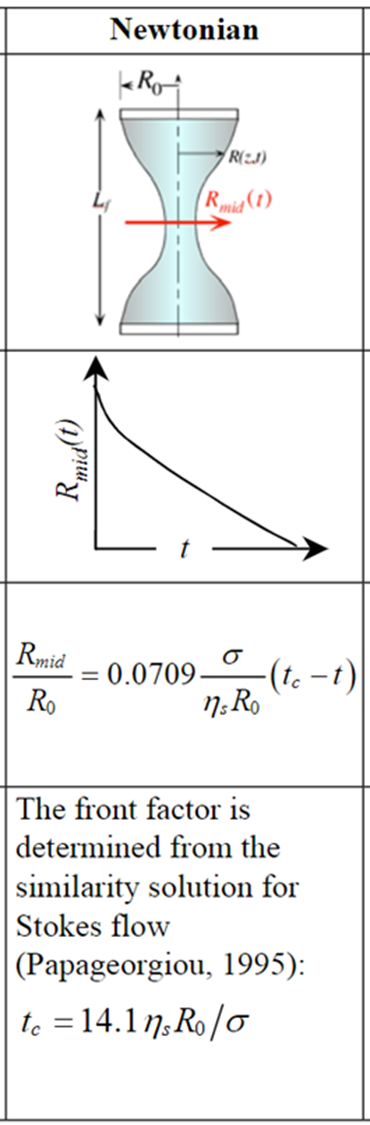


In [ ]:
caber_results = cv.fit_linear_caber(res_table['t_s'],
                                    res_table['radius_m'],
                                    strike_len_s=0.1,
                                    fps=100,
                                    eta_shear=6,            # Pa s, from shear rheometry
                                    surface_tension=40e-3,  # N/m
                                    filename=res_table['filename'].iloc[0],
                                    show_plot=True)


In [ ]:
for key, val in caber_results.items():
    if key == 'lmfit_result':
        continue
    print(f"{key:28s} {val}")
print()
print(caber_results['lmfit_result'].fit_report(min_correl=0.5))


In [ ]:
res_table.to_excel('res_table.xlsx')
print("saved res_table.xlsx")


## Notes

- `find_radius` reports `frame_height − tallest_background_column + 2`; once the filament
  has broken and the background spans the full frame height, the value wraps to 0 — that is
  the breakup signature, not a measurement artefact to fit.
- `fit_linear_caber` fits the visco-capillary linear regime
  $R(t) \approx 0.0709\,(\sigma/\eta)\,(14.1\,R_0\,\eta/\sigma - t)$ and converts the slope
  into an extensional viscosity $\eta_{ext} = -\sigma / (2\dot R)$ and a Trouton ratio
  $\mathrm{Tr} = \eta_{ext}/\eta_{shear}$.
- For real experiments replace the synthetic video with your own upload; tune the
  binarisation `thresh` in `find_radius_all` and the calibration (`fps`, `mmperpix`)
  to your camera.